In [29]:
import numpy as np

loaded = np.load("./datacache/final_points.npz")
final_points = {key: loaded[key] for key in loaded.files}
print(final_points)

{'task0_class0_feature': array([[-8.28581715e+00,  4.31562729e+01],
       [-1.45618320e+00,  3.61022148e+01],
       [-1.50476074e+01,  2.64006958e+01],
       [-8.79214764e+00,  4.75549507e+01],
       [-6.99962378e+00,  2.48035393e+01],
       [-8.76427937e+00,  4.27902565e+01],
       [-1.40557146e+01,  3.93097458e+01],
       [-1.01519136e+01,  3.74602165e+01],
       [-1.97997177e+00,  4.43317108e+01],
       [-7.74530745e+00,  2.99596691e+01],
       [-5.88480902e+00,  4.32145615e+01],
       [ 3.70153785e+00,  3.83641014e+01],
       [-6.67235613e+00,  3.31539307e+01],
       [ 3.25782448e-01,  3.75642204e+01],
       [ 3.58874297e+00,  2.97594719e+01],
       [ 1.69199681e+00,  3.28833885e+01],
       [-4.19475479e+01,  2.49794979e+01],
       [-1.04942894e+01,  3.92854614e+01],
       [-1.09700985e+01,  4.27070770e+01],
       [-1.82624092e+01,  2.96627026e+01],
       [-1.27391634e+01,  3.83457756e+01],
       [-4.49671249e+01,  2.26254311e+01],
       [ 1.68694735e+00,  3.8

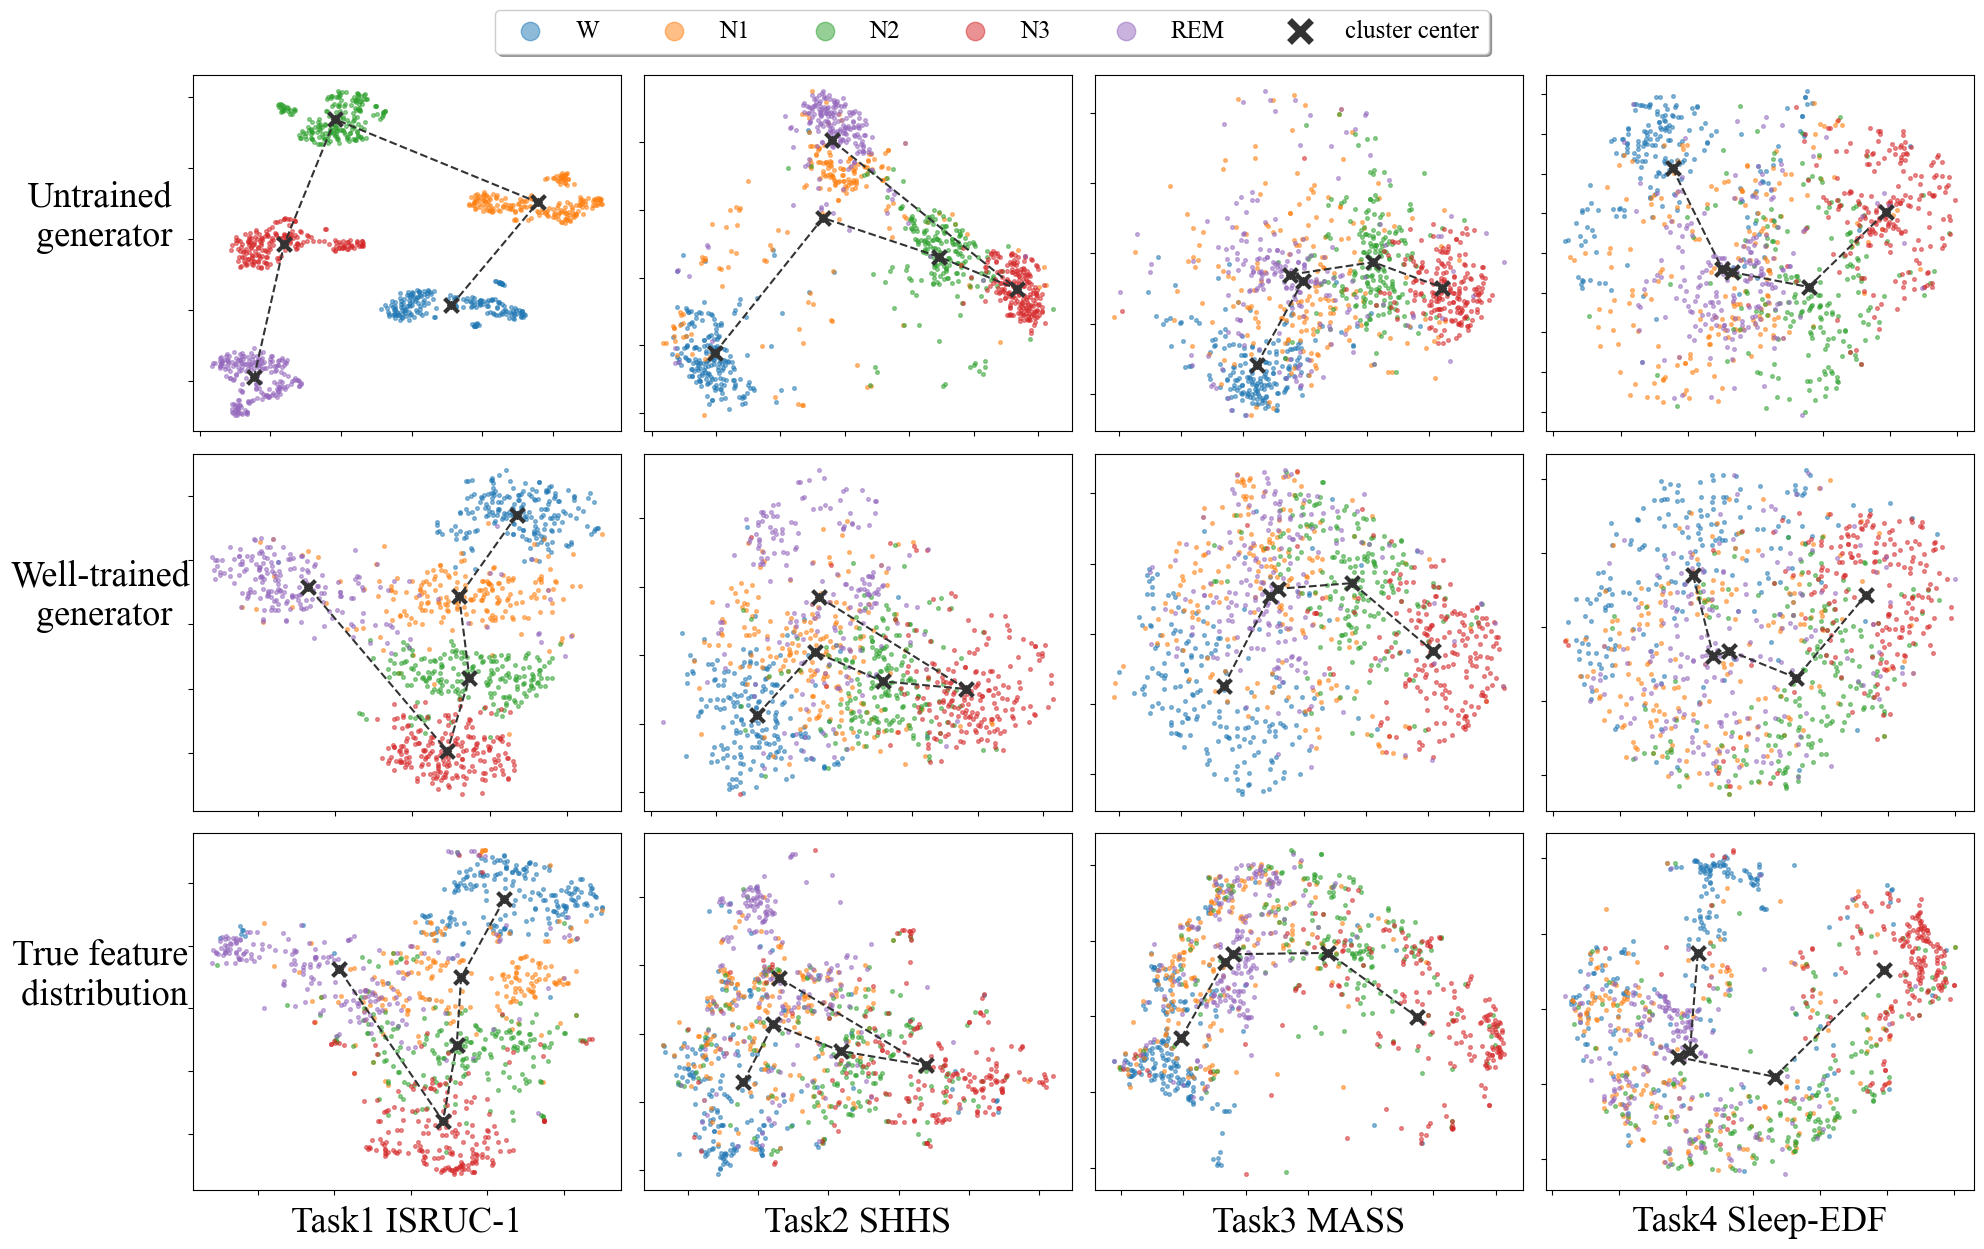

In [30]:
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection

#plt.style.use('seaborn-v0_8')  # 推荐专业风格：seaborn, bmh, ggplot
plt.rcParams.update({
    'font.family': 'Times New Roman',          # 字体（优先使用无衬线字体）
    'font.size': 12,                 # 基础字号
    'axes.titlesize': 14,            # 标题字号
    'axes.labelsize': 12,            # 坐标轴标签字号
    'xtick.labelsize': 10,           # X轴刻度字号
    'ytick.labelsize': 10,           # Y轴刻度字号
    'axes.grid': False,               # 显示网格
    'grid.alpha': 1,               # 网格透明度
    'axes.prop_cycle': plt.cycler(color=plt.cm.tab10.colors)  # 使用高对比度色环
})

num_tasks = 4
num_categories = 5

label_names = ['W', 'N1', 'N2', 'N3', 'REM']
dataset = ['ISRUC-1', 'SHHS', 'MASS', 'Sleep-EDF']

fig, axs = plt.subplots(3, 4, figsize=(20, 12))
def print_figure(feature_type: str, row: int):
    for t in range(num_tasks):
        centers = []
        subaxs = axs[row, t]
        if row == 2:
            subaxs.set_xlabel(f'Task{t + 1} {dataset[t]}', fontsize=26)
        if row == 0 and t == 0:
            subaxs.set_ylabel(f'Untrained\n generator', fontsize=26, rotation=0, va='bottom', ha='center', multialignment='center', labelpad=60)
        if row == 1 and t == 0:
            subaxs.set_ylabel(f'Well-trained\n generator', fontsize=26, rotation=0, va='bottom', ha='center', multialignment='center', labelpad=60)
        if row == 2 and t == 0:
            subaxs.set_ylabel(f'True feature\n distribution', fontsize=26, rotation=0, va='bottom', ha='center', multialignment='center', labelpad=60)
        for c in range(num_categories):
            points = final_points[f'task{t}_class{c}_' + feature_type]
            center = np.mean(points, axis=0)
            centers.append(center)
            subaxs.set_xticklabels([])  # 隐藏x轴刻度值
            subaxs.set_yticklabels([])  # 隐藏y轴刻度值
            subaxs.scatter(
                points[:, 0],
                points[:, 1],
                label=label_names[c],
                s=7,
                alpha=0.5,
                zorder=1
            )
        centers = np.array(centers)
        if t == 2 or t == 3:
            centers = centers[[0, 1, 4, 2, 3]]
        subaxs.scatter(
            centers[:, 0],
            centers[:, 1],
            marker='x',
            s=10,
            alpha=1,
            c='#333333',
            linewidth=5,
            zorder=5,
            label='cluster center'
        )
        subaxs.scatter(
            centers[:, 0],
            centers[:, 1],
            marker='x',
            s=100,
            alpha=1,
            c='#333333',
            linewidth=3,
            zorder=5,
        )
        subaxs.plot(
            centers[:, 0],
            centers[:, 1],
            linestyle='--', 
            color='#333333', 
            alpha=1, 
            linewidth=1.5,
            zorder=5
        )
print_figure('untrained_gen_feature', 0)
print_figure('gen_feature', 1)
print_figure('feature', 2)

handles, labels = axs[0, 0].get_legend_handles_labels()  # 从任一子图获取图例句柄
fig.legend(handles, labels, 
           loc='upper center',   # 置于画布顶部居中
           bbox_to_anchor=(0.5, 1.05),  # 微调位置（y轴偏移）
           ncol=6,              # 图例分2列排列
           frameon=True,        # 显示图例边框
           shadow=True,         # 添加阴影
           fontsize=18,
           markerscale=5.0)

plt.tight_layout()
plt.savefig('./figure/feature_vector.pdf', bbox_inches='tight')
plt.show()